# Egzamino rezultatų santrauka

Kirilas Šeršniovas, PEPfm-26. Pagrindinės metrikos, palyginimas, hipotezė, abliacijos ir reikalavimų įrodymai. **Mokymo paleisti nereikia.**

Atskirai: [SVM](svm_alternatyva.ipynb) · [MLP](mlp_alternatyva.ipynb) · [RBF](rbf_alternatyva.ipynb).

In [1]:
%matplotlib inline
from src.notebook_report import (
    load_results, table, key_metrics, comparison_plot, class_analysis,
    error_examples, robustness_analysis, ablations, interpretation, hypothesis)
# Skaitomi baigto eksperimento CSV. Modeliai čia nemokomi.
data = load_results()
print('Patikrinti rezultatai: 50 išorinių skaidinių, 7 variantai, 846 įrašai.')

from src.summary_plots import class_comparison, vehicle_groups, paired_comparison, all_robustness


Patikrinti rezultatai: 50 išorinių skaidinių, 7 variantai, 846 įrašai.


## Penkių pagrindinių metodų palyginimas

Pirminė metrika – Macro-F1, antrinė – balanced accuracy. SD yra sklaida, ne intervalas.

,Macro-F1 ± SD,Balanced accuracy ± SD,"Mokymas su paieška, s"
Metodas,,,
SVM RBF,0.842 ± 0.031,0.843 ± 0.030,3.812
MLP,0.775 ± 0.047,0.781 ± 0.044,5.481
RBF tinklas,0.727 ± 0.037,0.741 ± 0.034,9.524
5-NN,0.708 ± 0.053,0.714 ± 0.052,0.008
Artimiausias centroidas,0.441 ± 0.052,0.462 ± 0.047,0.007


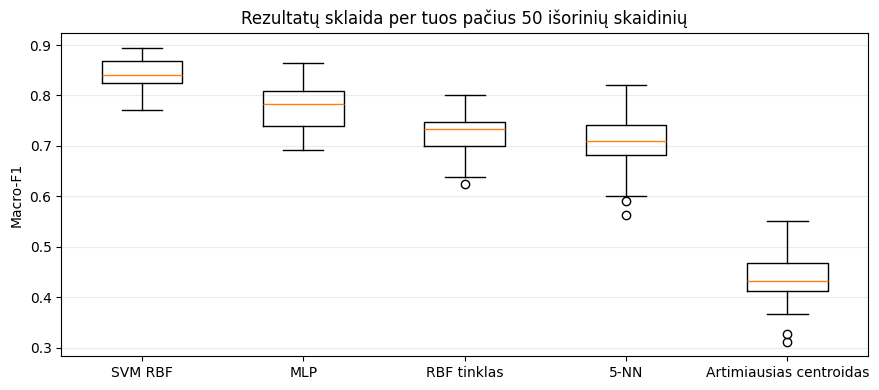

In [2]:
table(data)
comparison_plot(data)

## Kurias klases lengviausia atpažinti?

Visi penki metodai lyginami pagal tas pačias išorines prognozes. Kiekvienas įrašas kartojasi penkis kartus; F1 ir jautrumas skaičiuojami sujungus prognozes, o ne vidurkinant skaidinių metrikas.

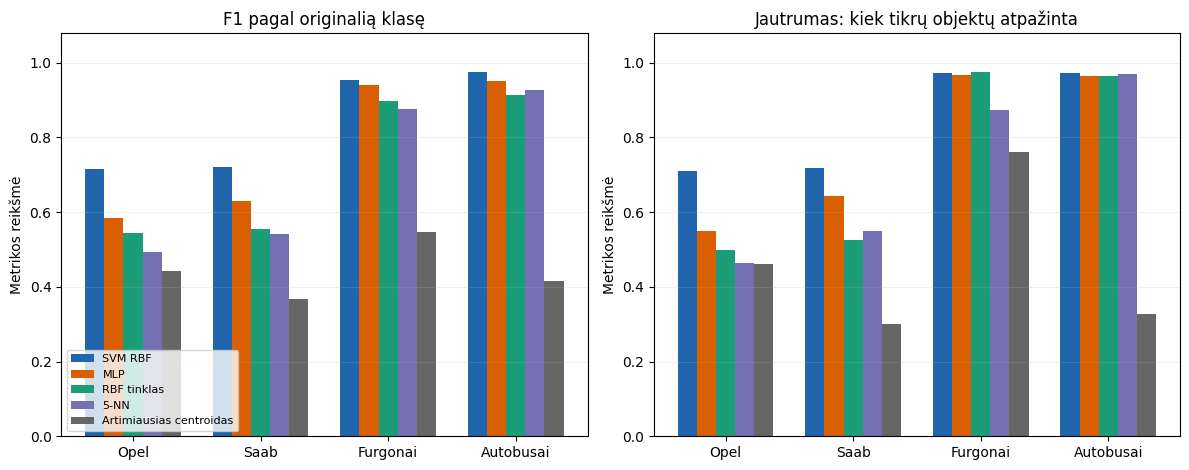

,SVM RBF,MLP,RBF tinklas,5-NN,Artimiausias centroidas
Klasės F1,,,,,
Opel,0.716,0.585,0.543,0.492,0.444
Saab,0.721,0.631,0.554,0.541,0.368
Furgonai,0.955,0.940,0.899,0.876,0.547
Autobusai,0.976,0.950,0.913,0.928,0.415


SVM silpniausia originali klasė pagal F1 – **Opel** (0.716). F1 apima preciziškumą ir jautrumą; jautrumas rodo, kokia tikrosios klasės dalis aptikta.

In [3]:
class_comparison(data)

## Lengvieji automobiliai, furgonai ir autobusai

Opel ir Saab sujungiami į lengvųjų automobilių grupę tiek tikrosiose žymėse, tiek prognozėse. Modeliai nepermokomi. Grupės skirtingo dydžio, todėl palyginimui naudojamos dalys ir F1, ne vien klaidų skaičius. Sujungtos metrikos nepakeičia pagrindinio keturių klasių vertinimo.

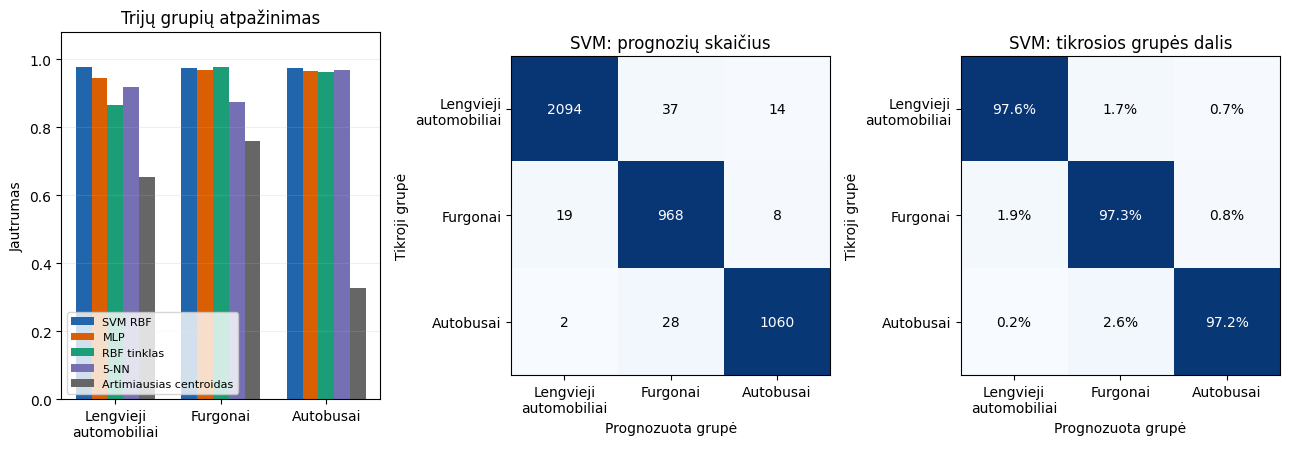

,Automobilių F1,Furgonų F1,Autobusų F1
Metodas,,,
SVM RBF,0.983,0.955,0.976
MLP,0.966,0.940,0.950
RBF tinklas,0.926,0.899,0.913
5-NN,0.936,0.876,0.928
Artimiausias centroidas,0.705,0.547,0.415


**SVM lengvųjų automobilių atveju:** tikslus Opel / Saab modelis atpažintas **71.4%**, o bendra automobilių grupė – **97.6%**. Sujungus klases, **563** Opel ↔ Saab klaidų tampa teisingais grupės atsakymais. Tai lengvesnė trijų grupių interpretacija, o ne naujai išmokytas modelis ar pagerėjusi keturių klasių metrika.

In [4]:
vehicle_groups(data)

## Ar pagrindinis SVM laimėjo?

In [5]:
interpretation(data, 'svm')
hypothesis(data)

**SVM RBF** vidutinis Macro-F1 yra **0.842**, skirtumas nuo geresnio baseline (5-NN) **+0.134**. Šis metodas laimėjo pagal iš anksto pasirinktą pirminę metriką. Geresni rezultatai nei tiesinio SVM ir SVM be standartizavimo dera su netiesinės ribos bei požymių mastelio svarbos paaiškinimu. Abliacijos neįrodo vienintelės priežasties.

SVM skirtumas nuo geresnio baseline: **+0.134**; pataisytas 95 % intervalas **[+0.097; +0.170]**; teigiami pakartojimai **5/5**. Hipotezė pagal nustatytą kriterijų: **patvirtinta**.

## Ar pranašumas kartojasi tuose pačiuose skaidiniuose?

Teigiamas skirtumas reiškia SVM pranašumą. Paskutinės dvi eilutės parodo branduolio ir standartizavimo abliacijas. Dėžutė apima kvartilius, linija žymi medianą; taškai – visi skaidiniai. 50 priklausomų skaidinių nėra 50 nepriklausomų eksperimentų, o pergalių skaičius nėra statistinio reikšmingumo įrodymas.

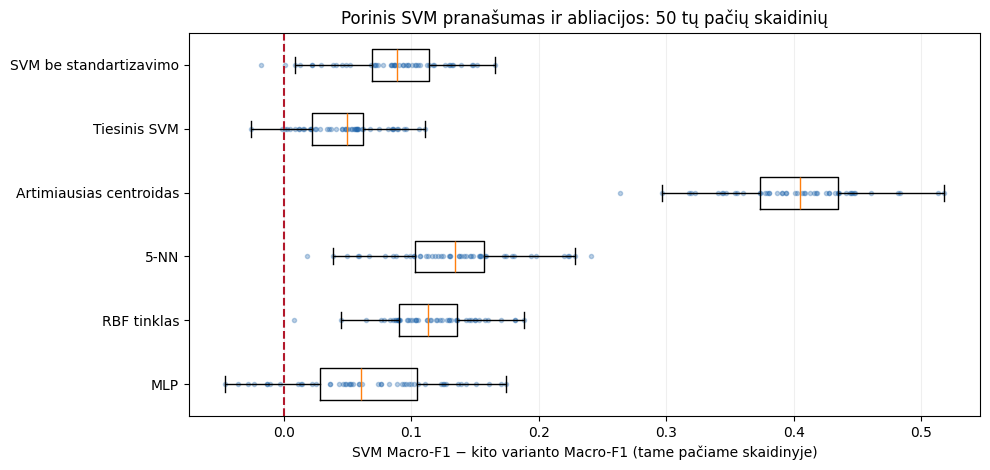

,Vidutinis skirtumas,"SVM geresnis, skaidinių",Lygiosios
Palyginimas su,,,
MLP,0.067,42,0
RBF tinklas,0.115,50,0
5-NN,0.134,50,0
Artimiausias centroidas,0.401,50,0
Tiesinis SVM,0.047,48,0
SVM be standartizavimo,0.086,49,0


In [6]:
paired_comparison(data)

## Abliacija ir požymių jautrumas

,Macro-F1 ± SD,Balanced accuracy ± SD,"Mokymas su paieška, s"
Metodas,,,
SVM RBF,0.842 ± 0.031,0.843 ± 0.030,3.812
Tiesinis SVM,0.794 ± 0.036,0.797 ± 0.036,2.012
SVM be standartizavimo,0.756 ± 0.040,0.765 ± 0.037,5.031


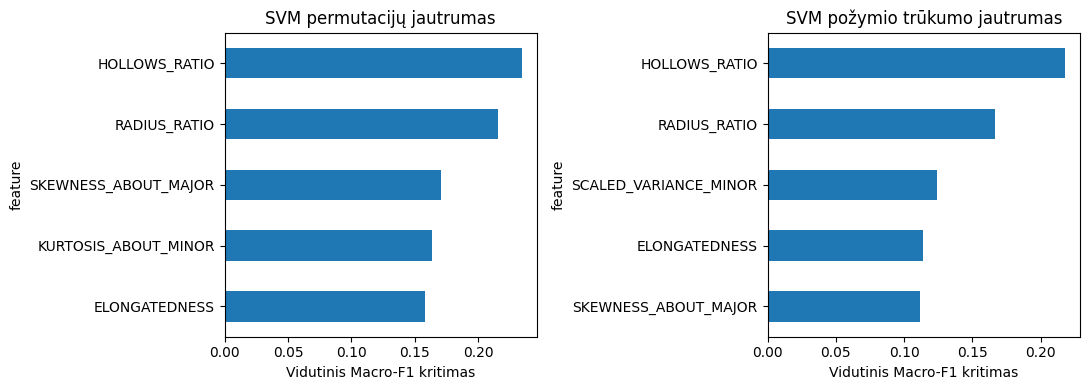

In [7]:
ablations(data)

## Visų penkių metodų atsparumas ir rezultatų kritimas

Trikdžiai taikyti tik išoriniam testui, visiems metodams vienodi. Triukšmo mastas remiasi mokymo dalies požymių standartiniais nuokrypiais; trūkstami langeliai užpildomi mokymo medianomis.

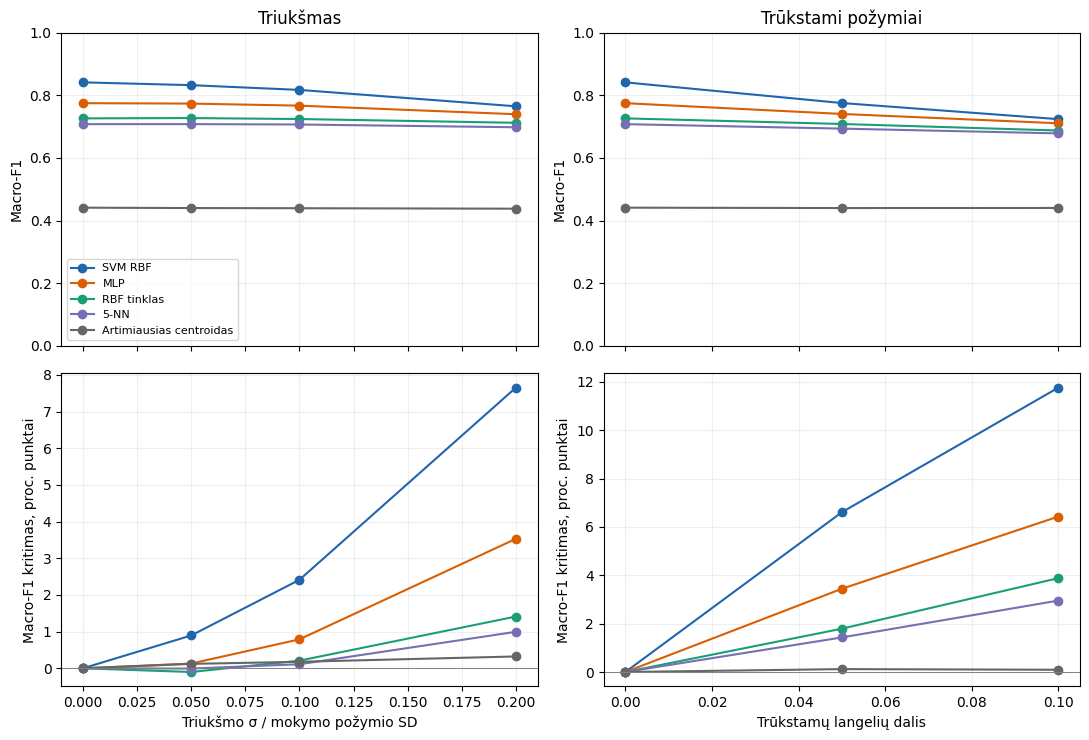

Viršuje matomas likęs atpažinimo lygis, apačioje – kritimas nuo kiekvieno metodo švaraus testo. Didžiausias kritimas savaime nereiškia prasčiausio galutinio rezultato. Taškai yra 50 skaidinių ir po 20 trikdžio realizacijų vidurkiai; nulinis lygis paimtas iš švaraus testo. Tai aprašomasis palyginimas, ne nepriklausomų imčių reikšmingumo testas.

In [8]:
all_robustness(data)

## Pagrindinio SVM klaidos

Čia 4 230 susijusių prognozių: kiekvienas iš 846 įrašų vertintas penkis kartus.

,Preciziškumas,Jautrumas,F1,Prognozių skaičius
bus,0.980,0.972,0.976,1090.0
opel,0.723,0.710,0.716,1060.0
saab,0.725,0.717,0.721,1085.0
van,0.937,0.973,0.955,995.0


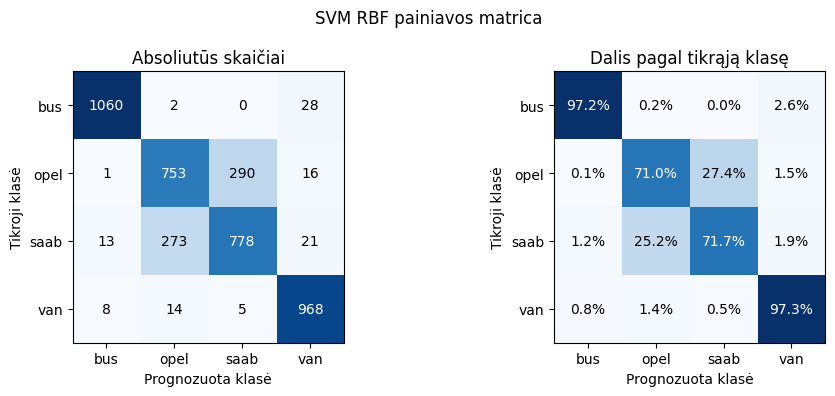

,Tikroji klasė,Dažniausia klaidinga klasė,Šios klaidos kartai,Visos klaidos iš 5
Įrašo indeksas,,,,
21,van,opel,5,5
23,bus,van,5,5
26,saab,opel,5,5
31,saab,van,5,5
32,opel,saab,5,5
58,opel,saab,5,5
65,opel,saab,5,5
72,opel,saab,5,5
77,saab,bus,5,5


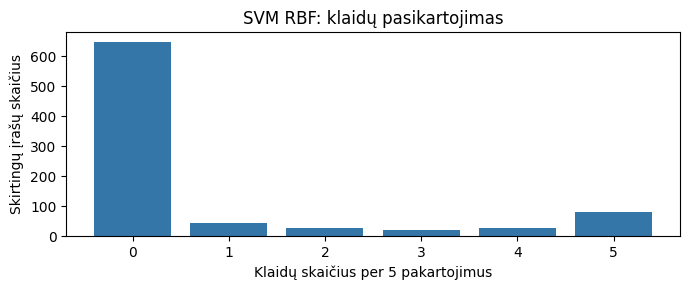

In [9]:
class_analysis(data, 'svm')
error_examples(data, 'svm')

## Protokolas ir ribos

846 įrašai, 18 požymių, keturios klasės. Visiems metodams naudoti tie patys **5 × 10 stratifikuoti išoriniai skaidiniai**. Parametrai parinkti atskira **5 dalių vidine CV** pagal Macro-F1. Medianų pildymas ir standartizavimas išmokti mokymo dalyse. Išorinis testas nenaudotas parinkimui.

**SD** yra skaidinių rezultatų standartinis nuokrypis, ne pasikliautinasis intervalas. Skaidiniai priklausomi. Klasių metrikose ir painiavos matricoje kiekvienas įrašas pasirodo penkis kartus – iš viso 4 230 prognozių vienam modeliui. Klasių metrikos skaičiuotos iš sujungtų prognozių, pagrindinis Macro-F1 – kaip 50 skaidinių vidurkis.

Tinklelių sumažinimas dėl biudžeto aprašytas [plano_patikslinimai.md](plano_patikslinimai.md). Rezultatai galioja mažam keturių modelių rinkiniui; realaus eismo ir naujų fizinių modelių veikimas nepatikrintas.

## Kur įrodyta kiekviena egzamino dalis?

| Reikalavimas | Įrodymas |
|---|---|
| Grandinė, baseline ir bent du intelektualieji metodai | `src/data.py`, `src/models.py`: medianos, standartizavimas, 5-NN, centroidas, SVM, MLP, RBF |
| Formulės ryšys su konkrečiu kodu | Kiekvieno metodo sąsiuvinio skyrius „Formulė ir konkreti kodo vieta“ |
| Tie patys skaidiniai ir metrikos, testas nenaudojamas derinimui | `run_experiment.py`, `results/main/run_config.yaml`, `inner_search/`, `verification.json` |
| Abliacija ir atsparumas | Šios santraukos grafikai ir lentelės, išsamūs CSV `results/main/` |
| Rezultatai, klaidos ir paaiškinimas | Ši santrauka, trys modelių sąsiuviniai, [pilna ataskaita](results/main/report.md) |
| Instrukcija, priklausomybės, sėklos, viena komanda | [README.md](README.md), `requirements.txt`, `configs/main.yaml`; `python run_experiment.py --config configs/main.yaml` |
| AI naudojimo auditas | [ai_log.md](ai_log.md): užklausos, priimti ir atmesti pasiūlymai, klaidos ir patikros |
| Gyvas gynimas | **Dar neatliktas.** Studentas paaiškina formulę, paleidžia dėstytojo įrašą per `predict.py` ir padaro mažą pakeitimą. Instrukcija README. |

Koliokviumo planas ir galutinis kodas nėra pažodžiui identiški: tinklelių ir versijų registravimo patikslinimai atskleisti [plano_patikslinimai.md](plano_patikslinimai.md). AI žurnalas nepakeičia studento gebėjimo paaiškinti savo darbą.

## Vykdymo patikra ir ištekliai

In [10]:
import json
from IPython.display import display
for name in ['verification.json', 'resources.json']:
    print(name)
    display(json.loads((data['root'] / name).read_text(encoding='utf-8')))

verification.json


{'status': 'passed',
 'verification_peak_rss_bytes': 155881472,
 'fit_budget_checked': True,
 'inner_search_tables': 251,
 'model_fits': 18951,
 'runtime_and_memory_checked': True,
 'outer_splits': 50,
 'model_variants': 7,
 'fold_records': 350,
 'prediction_records': 29610,
 'robustness_records': 25000,
 'permutation_records': 900,
 'data_md5': 'fbba18157b188f309d772f9ca4e578f5',
 'manual_metric_recalculation': True,
 'same_test_indices_for_all_models': True,
 'final_model_predicts': True}

resources.json


{'model_fits': 18951,
 'wall_seconds_before_reporting': 1597.890906799992,
 'peak_process_rss_bytes': 242561024,
 'jobs': 1,
 'native_thread_limit': 4,
 'scope': 'Main process: training, predictions, diagnostics and figure generation; reporting subprocess excluded',
 'within_fit_budget': True,
 'within_time_budget': True,
 'within_memory_budget': True,
 'report_peak_rss_bytes': 183533568,
 'verification_peak_rss_bytes': 153518080,
 'workflow_peak_rss_upper_bound_bytes': 426094592,
 'first_report_completed_utc': '2026-09-21T17:26:32.855957+00:00',
 'seconds_from_manifest_to_first_report': 1607.343789,
 'whole_workflow_memory_within_2gb': True}